## **Quadratic Equation Workflow**

In [5]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict,Literal

In [31]:
# 1. defining the state class

class QuadState(TypedDict):

    a:int 
    b:int
    c:int 

    equation:str 
    discriminant:str
    result:str 


In [38]:
# 4. Build the agents/tools/functions required 

def show_equation(state:QuadState):

    equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'
    return {"euation":equation}


def calculate_discriminant(state:QuadState):

    discriminant = state['b']**2  - 4*state['a']*state['c']

    return {"discriminant":discriminant}


def real_roots(state:QuadState):

    root1 = (-state["b"]+ state["discriminant"]**0.5)/(2*state['a'])
    root2 = (-state["b"]- state["discriminant"]**0.5)/(2*state['a'])
    
    result = f"The roots are {root1},{root2}"

    return {"result":result}


def repeated_roots(state:QuadState):

    root = (-state['b'])/(2*state['a'])
    result = f"Only repeated root is {root}"

    return {'result':result}

def no_real_roots(state:QuadState):

    result = "No real roots"

    return {"result":result}



def check_condition(state:QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:

    if state['discriminant'] >0:
        return "real_roots"
    
    elif state['discriminant']==0:
        return "repeated_roots"
    
    else:
        return "no_real_roots"




In [39]:
# 2. defining graph

graph = StateGraph(QuadState)

In [40]:
# 3. Adding nodes 

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)


In [41]:
# 5. Add the edges 

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')

# here the braking point "the conditional edge"
graph.add_conditional_edges("calculate_discriminant",check_condition)

# and here we are adding the adge after checking the condition 
graph.add_edge('real_roots',END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_real_roots",END)

# 5. Compile the workflow 
workflow = graph.compile()

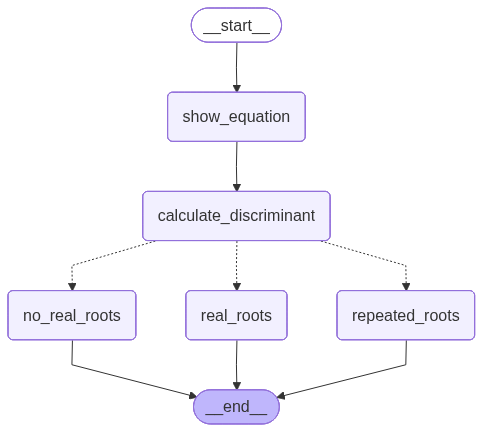

In [42]:
workflow

 -- Dotted line indicates the conditional edge

In [43]:
inintial_state = {
    'a':2,
    'b':5,
    'c':1
}

workflow.invoke(inintial_state)

{'a': 2,
 'b': 5,
 'c': 1,
 'discriminant': 17,
 'result': 'The roots are -0.21922359359558485,-2.2807764064044154'}